# Détection descriptive des doublets avec Scrublet

Scrublet est exécuté séparément pour chacun des 20 échantillons après QC. Aucune cellule n'est filtrée.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

## Chargement et vérifications préalables

In [2]:
adata = sc.read_h5ad("../data/processed/GSE149689_qc.h5ad")
figure_dir = Path("../results/figures/doublets")
figure_dir.mkdir(parents=True, exist_ok=True)
n_cells_initial = adata.n_obs

print("Dimensions :", adata.shape)
print("Présence de sample_id :", "sample_id" in adata.obs.columns)
sample_counts_before = adata.obs["sample_id"].value_counts()
sample_order = sorted(sample_counts_before.index, key=lambda value: int(value.removeprefix("Sample")))
display(sample_counts_before.reindex(sample_order))

matrix_values = adata.X.data if sparse.issparse(adata.X) else np.asarray(adata.X).ravel()
row_sums = np.asarray(adata.X.sum(axis=1)).ravel()
raw_count_checks = {
    "matrix_is_sparse": sparse.issparse(adata.X),
    "counts_are_nonnegative": bool((matrix_values >= 0).all()),
    "counts_are_integer_valued": bool(np.all(matrix_values == np.floor(matrix_values))),
    "row_sums_match_total_counts": bool(np.allclose(row_sums, adata.obs["total_counts"])),
    "doublet_columns_absent": not {"doublet_score", "predicted_doublet"}.intersection(adata.obs.columns),
}
print("Format de X :", adata.X.format.upper() if sparse.issparse(adata.X) else type(adata.X).__name__)
print("Type de X :", adata.X.dtype)
print("Contrôles des counts bruts :", raw_count_checks)
if not all(raw_count_checks.values()):
    raise AssertionError({name: passed for name, passed in raw_count_checks.items() if not passed})

Dimensions : (59572, 33538)
Présence de sample_id : True


sample_id
Sample1     4464
Sample2     4999
Sample3     4895
Sample4     1331
Sample5     4331
Sample6     2601
Sample7     1040
Sample8      652
Sample9      398
Sample10     714
Sample11    3978
Sample12    4526
Sample13    4646
Sample14    4490
Sample15    1502
Sample16    1873
Sample17    1345
Sample18    3239
Sample19    4123
Sample20    4425
Name: count, dtype: int64

Format de X : CSC
Type de X : float32
Contrôles des counts bruts : {'matrix_is_sparse': True, 'counts_are_nonnegative': True, 'counts_are_integer_valued': True, 'row_sums_match_total_counts': True, 'doublet_columns_absent': True}


## Scrublet séparément par échantillon

In [3]:
adata.obs["doublet_score"] = np.nan
adata.obs["predicted_doublet"] = pd.Series(pd.NA, index=adata.obs_names, dtype="boolean")

for sample in sample_order:
    print(f"Scrublet : {sample} ({sample_counts_before[sample]} cellules)")
    sample_adata = adata[adata.obs["sample_id"] == sample].copy()
    sc.pp.scrublet(sample_adata, random_state=42)
    adata.obs.loc[sample_adata.obs_names, "doublet_score"] = sample_adata.obs["doublet_score"].to_numpy()
    adata.obs.loc[sample_adata.obs_names, "predicted_doublet"] = sample_adata.obs["predicted_doublet"].to_numpy(dtype=bool)

adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype(bool)

Scrublet : Sample1 (4464 cellules)


Scrublet : Sample2 (4999 cellules)


Scrublet : Sample3 (4895 cellules)


Scrublet : Sample4 (1331 cellules)


Scrublet : Sample5 (4331 cellules)


...

Scrublet : Sample16 (1873 cellules)


Scrublet : Sample17 (1345 cellules)


Scrublet : Sample18 (3239 cellules)


Scrublet : Sample19 (4123 cellules)


Scrublet : Sample20 (4425 cellules)


## Résumé par échantillon

In [4]:
doublet_summary = (
    adata.obs.groupby("sample_id", observed=True)
    .agg(
        n_cells=("predicted_doublet", "size"),
        n_predicted_doublets=("predicted_doublet", "sum"),
        median_doublet_score=("doublet_score", "median"),
        mean_doublet_score=("doublet_score", "mean"),
        maximum_doublet_score=("doublet_score", "max"),
    ).reset_index()
)
doublet_summary["pct_predicted_doublets"] = 100 * doublet_summary["n_predicted_doublets"] / doublet_summary["n_cells"]
doublet_summary = doublet_summary[["sample_id", "n_cells", "n_predicted_doublets", "pct_predicted_doublets", "median_doublet_score", "mean_doublet_score", "maximum_doublet_score"]]
doublet_summary_sorted = doublet_summary.sort_values("pct_predicted_doublets", ascending=False)
display(doublet_summary_sorted)

,sample_id,n_cells,n_predicted_doublets,pct_predicted_doublets,median_doublet_score,mean_doublet_score,maximum_doublet_score
18,Sample19,4123,112,2.716469,0.053815,0.065555,0.558140
12,Sample13,4646,107,2.303056,0.035988,0.048853,0.573034
10,Sample11,3978,90,2.262443,0.035294,0.050478,0.558140
17,Sample18,3239,71,2.192035,0.036930,0.053894,0.525000
19,Sample20,4425,79,1.785311,0.034279,0.049918,0.565714
16,Sample17,1345,24,1.784387,0.039080,0.049529,0.415385
11,Sample12,4526,72,1.590809,0.037394,0.051229,0.573034
9,Sample10,714,11,1.540616,0.043624,0.053978,0.339130
6,Sample7,1040,14,1.346154,0.032407,0.048544,0.387097
0,Sample1,4464,55,1.232079,0.032967,0.050889,0.565714


## Visualisations

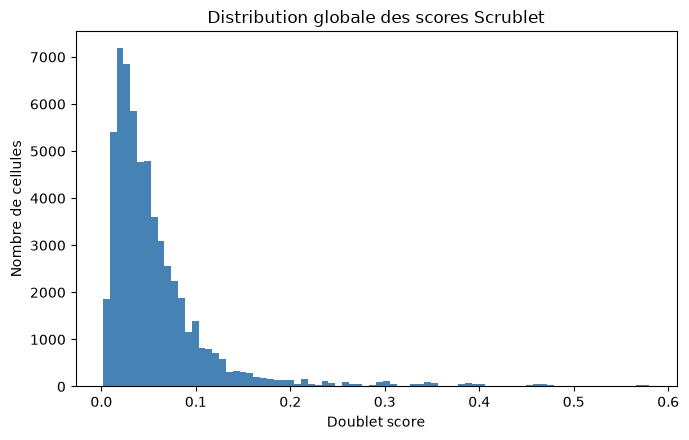

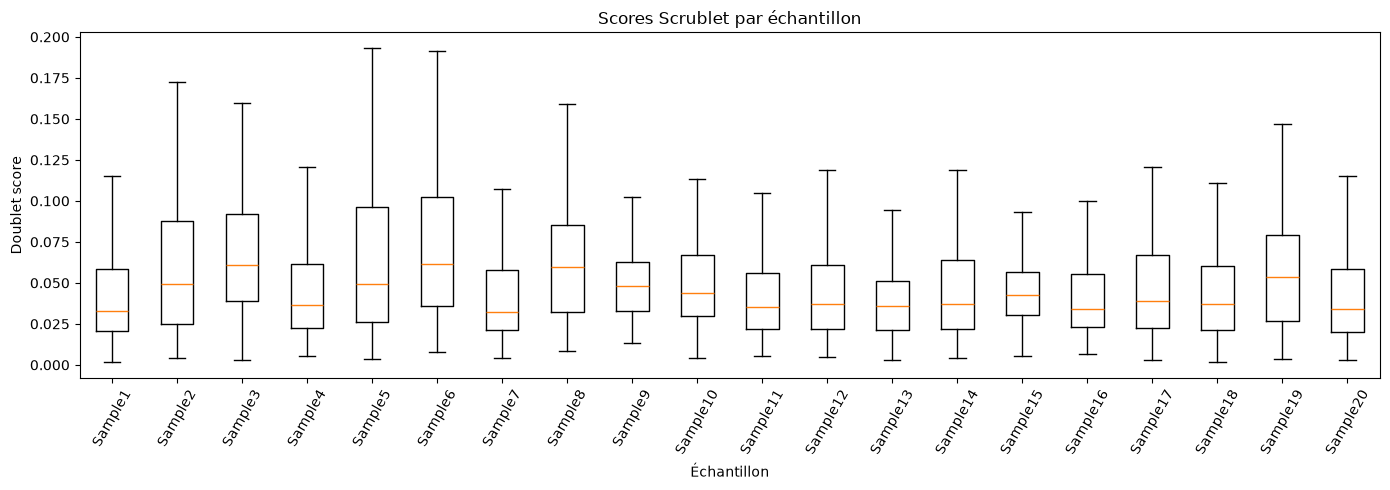

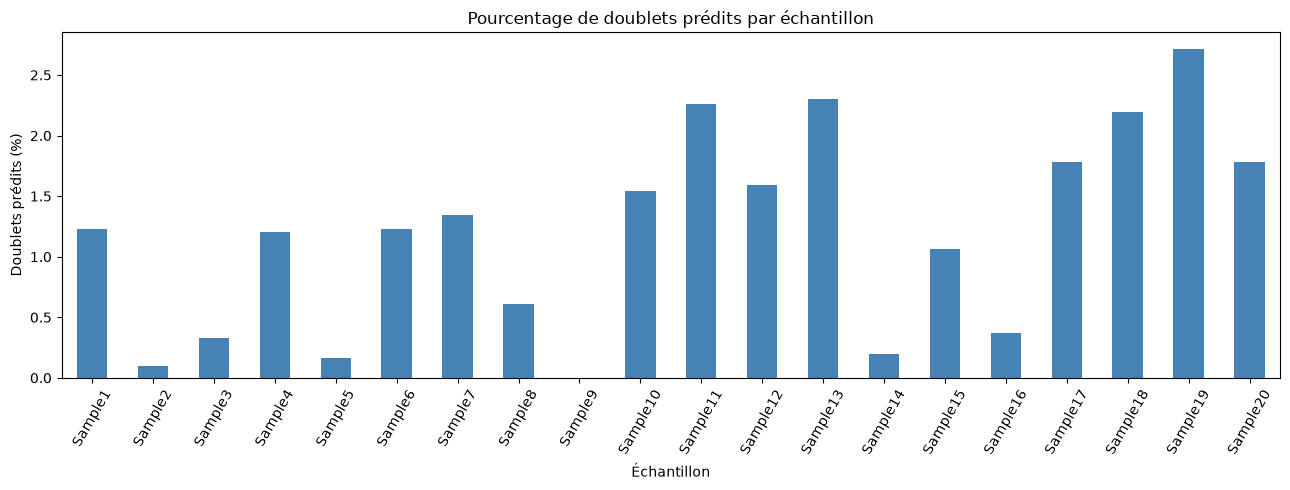

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(adata.obs["doublet_score"], bins=80, color="steelblue", edgecolor="none")
ax.set_xlabel("Doublet score"); ax.set_ylabel("Nombre de cellules")
ax.set_title("Distribution globale des scores Scrublet")
fig.tight_layout()
fig.savefig(figure_dir / "doublet_score_global_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

scores_by_sample = [adata.obs.loc[adata.obs["sample_id"] == sample, "doublet_score"] for sample in sample_order]
fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(scores_by_sample, tick_labels=sample_order, showfliers=False)
ax.set_xlabel("Échantillon"); ax.set_ylabel("Doublet score")
ax.set_title("Scores Scrublet par échantillon")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
fig.savefig(figure_dir / "doublet_score_by_sample.png", dpi=150, bbox_inches="tight")
plt.show()

plot_summary = doublet_summary.set_index("sample_id").reindex(sample_order)
fig, ax = plt.subplots(figsize=(13, 5))
plot_summary["pct_predicted_doublets"].plot.bar(ax=ax, color="steelblue")
ax.set_xlabel("Échantillon"); ax.set_ylabel("Doublets prédits (%)")
ax.set_title("Pourcentage de doublets prédits par échantillon")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
fig.savefig(figure_dir / "predicted_doublet_percentage_by_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## Contrôles finaux et comparaison descriptive

In [6]:
final_checks = {
    "no_missing_doublet_score": not adata.obs["doublet_score"].isna().any(),
    "no_missing_predicted_doublet": not adata.obs["predicted_doublet"].isna().any(),
    "predicted_doublet_is_boolean": pd.api.types.is_bool_dtype(adata.obs["predicted_doublet"]),
    "no_cells_removed": adata.n_obs == n_cells_initial,
    "sample_counts_unchanged": adata.obs["sample_id"].value_counts().reindex(sample_order).equals(sample_counts_before.reindex(sample_order)),
}
if not all(final_checks.values()):
    raise AssertionError({name: passed for name, passed in final_checks.items() if not passed})
print("Contrôles finaux :", ", ".join(f"{name}=OK" for name in final_checks))

display(
    adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt", "doublet_score", "predicted_doublet"]]
    .groupby("predicted_doublet").median()
)

Contrôles finaux : no_missing_doublet_score=OK, no_missing_predicted_doublet=OK, predicted_doublet_is_boolean=OK, no_cells_removed=OK, sample_counts_unchanged=OK


,total_counts,n_genes_by_counts,pct_counts_mt,doublet_score
predicted_doublet,,,,
False,5563.0,1806.0,7.095344,0.040640
True,11294.0,3037.0,6.961349,0.382114


## Résumé descriptif

In [7]:
n_predicted = int(adata.obs["predicted_doublet"].sum())
pct_predicted = 100 * n_predicted / adata.n_obs
highest_sample = doublet_summary_sorted.iloc[0]
lowest_sample = doublet_summary_sorted.iloc[-1]
print(f"Scrublet prédit {n_predicted:,} doublets potentiels sur {adata.n_obs:,} cellules ({pct_predicted:.2f} %).")
print(f"La proportion par échantillon varie de {lowest_sample['pct_predicted_doublets']:.2f} % ({lowest_sample['sample_id']}) à {highest_sample['pct_predicted_doublets']:.2f} % ({highest_sample['sample_id']}).")
print("Résumé descriptif uniquement : aucune cellule n'est filtrée et aucun seuil n'est modifié manuellement.")

Scrublet prédit 747 doublets potentiels sur 59,572 cellules (1.25 %).
La proportion par échantillon varie de 0.00 % (Sample9) à 2.72 % (Sample19).
Résumé descriptif uniquement : aucune cellule n'est filtrée et aucun seuil n'est modifié manuellement.


## Validation des appels Scrublet

In [8]:
validation_source = sc.read_h5ad("../data/processed/GSE149689_qc.h5ad")
diagnostic_dir = figure_dir / "score_distributions"
diagnostic_dir.mkdir(parents=True, exist_ok=True)
previous_scores = adata.obs["doublet_score"].copy()
previous_predictions = adata.obs["predicted_doublet"].copy()

In [9]:
validation_rows = []
parameter_rows = []
for sample in sample_order:
    print(f"Validation Scrublet : {sample}")
    sample_adata = validation_source[validation_source.obs["sample_id"] == sample].copy()
    sc.pp.scrublet(sample_adata, random_state=42)

    scores_reproduced = np.allclose(
        sample_adata.obs["doublet_score"].to_numpy(),
        previous_scores.loc[sample_adata.obs_names].to_numpy(),
        rtol=0, atol=0,
    )
    predictions_reproduced = np.array_equal(
        sample_adata.obs["predicted_doublet"].to_numpy(dtype=bool),
        previous_predictions.loc[sample_adata.obs_names].to_numpy(dtype=bool),
    )

    scrublet_uns = sample_adata.uns["scrublet"]
    parameter_rows.append({
        "sample_id": sample,
        "available_keys": tuple(scrublet_uns.keys()),
        **scrublet_uns.get("parameters", {}),
    })
    validation_rows.append({
        "sample_id": sample,
        "n_cells": sample_adata.n_obs,
        "n_predicted_doublets": int(sample_adata.obs["predicted_doublet"].sum()),
        "pct_predicted_doublets": 100 * sample_adata.obs["predicted_doublet"].mean(),
        "median_doublet_score": sample_adata.obs["doublet_score"].median(),
        "maximum_doublet_score": sample_adata.obs["doublet_score"].max(),
        "scores_reproduced": scores_reproduced,
        "predictions_reproduced": predictions_reproduced,
    })

    sc.pl.scrublet_score_distribution(sample_adata, show=False)
    fig = plt.gcf()
    fig.suptitle(f"Scrublet score distribution — {sample}")
    fig.savefig(diagnostic_dir / f"{sample}_scrublet_score_distribution.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

Validation Scrublet : Sample1


Validation Scrublet : Sample2


Validation Scrublet : Sample3


Validation Scrublet : Sample4


Validation Scrublet : Sample5


...

Validation Scrublet : Sample16


Validation Scrublet : Sample17


Validation Scrublet : Sample18


Validation Scrublet : Sample19


Validation Scrublet : Sample20


In [10]:
validation_summary = pd.DataFrame(validation_rows)
scrublet_parameters = pd.DataFrame(parameter_rows)
if not validation_summary[["scores_reproduced", "predictions_reproduced"]].all().all():
    raise AssertionError("Les résultats Scrublet ne sont pas exactement reproductibles.")
display(validation_summary[[
    "sample_id", "n_cells", "n_predicted_doublets",
    "pct_predicted_doublets", "median_doublet_score", "maximum_doublet_score",
]])
print("Clés et paramètres disponibles dans sample_adata.uns['scrublet'] :")
display(scrublet_parameters)
print("Reproductibilité exacte des scores et prédictions : OK pour les 20 échantillons.")
print("Nombre de cellules inchangé :", validation_summary["n_cells"].sum() == adata.n_obs)

,sample_id,n_cells,n_predicted_doublets,pct_predicted_doublets,median_doublet_score,maximum_doublet_score
0,Sample1,4464,55,1.232079,0.032967,0.565714
1,Sample2,4999,5,0.100020,0.049340,0.580110
2,Sample3,4895,16,0.326864,0.060606,0.580110
3,Sample4,1331,16,1.202104,0.036384,0.415385
4,Sample5,4331,7,0.161625,0.049301,0.565714
5,Sample6,2601,32,1.230296,0.061224,0.506494
6,Sample7,1040,14,1.346154,0.032407,0.387097
7,Sample8,652,4,0.613497,0.059794,0.250000
8,Sample9,398,0,0.000000,0.047836,0.155556
9,Sample10,714,11,1.540616,0.043624,0.339130


Clés et paramètres disponibles dans sample_adata.uns['scrublet'] :


,sample_id,available_keys,expected_doublet_rate,sim_doublet_ratio,n_neighbors,random_state
0,Sample1,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,33,42
1,Sample2,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,35,42
2,Sample3,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,35,42
3,Sample4,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,18,42
4,Sample5,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,33,42
5,Sample6,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,26,42
6,Sample7,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,16,42
7,Sample8,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,13,42
8,Sample9,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,10,42
9,Sample10,"(doublet_scores_sim, doublet_parents, paramete...",0.05,2.0,13,42


Reproductibilité exacte des scores et prédictions : OK pour les 20 échantillons.
Nombre de cellules inchangé : True


## Final doublet filtering

In [11]:
doublet_table_dir = Path("../results/tables/doublets")
doublet_table_dir.mkdir(parents=True, exist_ok=True)
doublet_table_path = doublet_table_dir / "predicted_doublets.csv"

doublet_columns = [
    "sample_id", "subject_id", "disease", "severity",
    "doublet_score", "total_counts", "n_genes_by_counts", "pct_counts_mt",
]
predicted_doublets = adata.obs.loc[adata.obs["predicted_doublet"], doublet_columns].copy()
predicted_doublets.insert(0, "barcode", predicted_doublets.index.astype(str))
predicted_doublets.to_csv(doublet_table_path, index=False)

singlet_mask = ~adata.obs["predicted_doublet"]
adata_singlets = adata[singlet_mask].copy()

n_cells_initial = adata.n_obs
n_doublets_removed = int((~singlet_mask).sum())
n_cells_final = adata_singlets.n_obs
pct_removed = 100 * n_doublets_removed / n_cells_initial

print("Cellules initiales :", n_cells_initial)
print("Doublets retirés :", n_doublets_removed)
print("Cellules finales :", n_cells_final)
print(f"Pourcentage retiré : {pct_removed:.2f} %")
print("\nCellules restantes par sample_id :")
display(adata_singlets.obs["sample_id"].value_counts().reindex(sample_order).rename("n_cells").to_frame())
print("Cellules restantes par disease :")
display(adata_singlets.obs["disease"].value_counts().rename("n_cells").to_frame())

no_predicted_doublets = adata_singlets.obs["predicted_doublet"].sum() == 0
all_samples_retained = adata_singlets.obs["sample_id"].nunique() == 20
x_is_sparse = sparse.issparse(adata_singlets.X)
if not x_is_sparse:
    raise AssertionError("adata_singlets.X n'est pas sparse.")
x_values = adata_singlets.X.data
counts_nonnegative = bool(np.all(x_values >= 0))
counts_integer_valued = bool(np.all(np.equal(x_values, np.floor(x_values))))
no_log1p_metadata = "log1p" not in adata_singlets.uns

checks = {
    "no_predicted_doublets": bool(no_predicted_doublets),
    "all_20_samples_retained": bool(all_samples_retained),
    "X_is_sparse": bool(x_is_sparse),
    "counts_nonnegative": counts_nonnegative,
    "counts_integer_valued": counts_integer_valued,
    "no_log1p_metadata": no_log1p_metadata,
    "doublet_columns_retained": {"doublet_score", "predicted_doublet"}.issubset(adata_singlets.obs.columns),
}
display(pd.Series(checks, name="passed").to_frame())
if not all(checks.values()):
    raise AssertionError(f"Échec des contrôles finaux : {checks}")
if n_doublets_removed != 747:
    raise AssertionError(f"747 doublets attendus, {n_doublets_removed} obtenus.")

singlet_path = Path("../data/processed/GSE149689_singlets.h5ad")
adata_singlets.write_h5ad(singlet_path)
print("Table exportée :", doublet_table_path)
print("Objet AnnData sauvegardé :", singlet_path)

Cellules initiales : 59572
Doublets retirés : 747
Cellules finales : 58825
Pourcentage retiré : 1.25 %

Cellules restantes par sample_id :


,n_cells
sample_id,
Sample1,4409
Sample2,4994
Sample3,4879
Sample4,1315
Sample5,4324
Sample6,2569
Sample7,1026
Sample8,648
Sample9,398


Cellules restantes par disease :


,n_cells
disease,
COVID-19,31033
healthy_control,17355
influenza,10437


,passed
no_predicted_doublets,True
all_20_samples_retained,True
X_is_sparse,True
counts_nonnegative,True
counts_integer_valued,True
no_log1p_metadata,True
doublet_columns_retained,True


Table exportée : ../results/tables/doublets/predicted_doublets.csv
Objet AnnData sauvegardé : ../data/processed/GSE149689_singlets.h5ad


Scrublet a été appliqué indépendamment aux 20 échantillons. Au total, 747 cellules (1,25 %) ont été prédites comme doublets. Les appels automatiques ont été conservés sans modification manuelle des seuils. Les cellules prédites comme doublets présentaient des nombres de counts et de gènes nettement plus élevés que les singlets.